# Assessing credibility in Bayesian Networks structure learning
#### Authors: 
1. **Vitor Barth** (vitor.barth@usp.br) <br> University of Sao Paulo 

2. **Fábio Serrão** (carlos.maciel@unesp.br) <br> State University of Sao Paulo

3. **Carlos Maciel** (fserrao@ufscar.br) <br> Federal University of São Carlos

## 0. Dependencies

In [235]:
import cloudpickle
import logging

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns

from datetime import timedelta
from timeit import default_timer as timer
from tqdm import tqdm

# Bayesian Networks Libs
from pgmpy.estimators import HillClimbSearch, BicScore, BDeuScore
from pgmpy.models import BayesianNetwork

logger = logging.getLogger()
logger.setLevel(logging.CRITICAL)

%config InlineBackend.figure_format='retina'

## 1. Model

### 1.1. States

In [15]:
STATES = { 
    0: "No Edge", 
    1: "A -> B", 
    2: "A <- B" 
}

### 1.2. Priors

#### True Fraction:
Serves as a hyperparameter of the Dirichlet-Multinomial model of the observed distributions. 
<br> The *posterior* is expected to model the true distribution of each state.

* **Distribution:** Dirichlet 
* **Parameters:** 
    - $\alpha$: Concentration
    <br> *Default*: `[1, 1, 1]` 

#### Concentration:
Will be used as a hyperparameter of the Dirichlet-Multinomial *posterior* model.

* **Distribution:** Log-Normal 
* **Parameters:** 
    - $\mu$: Logarithm of the Location
      <br> *Default*: `1`
    - $\sigma$: Logarithm of the Scale.
      <br> *Default*: `1`

#### Observed Fraction:
The Multinomial model of the observed distributions of each state.

* **Model:** Dirichlet-Multinomial 
* **Parameters:** 
    - $n$: Number of observations
    - $a$: Observed concentration of each state
      <br> *Default*: `true_fraction * concentration$`

In [16]:
TRUE_FRACTION_OF_EACH_STATE_ALPHA = [1/3, 1/3, 1/3]
CONCENTRATION_MU = 1.5
CONCENTRATION_SIGMA = 1.5

### 1.3 Learning the Distributions

In [30]:
def learn_edge_distribution(observations,
                            edge=[],
                            destination_folder="", 
                            experiment_identifier="", 
                            mcmc_alg=pm.NUTS, 
                            chains=10, 
                            burnin=10000, 
                            draws=10000, 
                            nthreads=4):
    
    if (destination_folder != "" and len(edge) != 2):
        raise Exception("The edge must be indicated when saving the model") 

    num_observations = len(observations)
    
    with pm.Model() as model:            
        frac = pm.Dirichlet("true_fraction", 
                            a=TRUE_FRACTION_OF_EACH_STATE_ALPHA)
        
        conc = pm.Lognormal("concentration", 
                            mu=CONCENTRATION_MU, 
                            sigma=CONCENTRATION_SIGMA)

        
        counts = pm.DirichletMultinomial(
            "observed_counts", 
            n=1,
            a=frac * conc, 
            shape=(num_observations, 3), 
            observed=observations
        )

        trace = pm.sample(chains=chains, 
                          tune=burnin, 
                          draws=draws, 
                          step=mcmc_alg(), 
                          return_inferencedata=False, 
                          cores=nthreads)

        # Saves if a destination is passed
        if (destination_folder != ""):
            posteriori = cloudpickle.dumps({
                            'model': model, 
                            'experiment_identifier': experiment_identifier,
                            'edge': edge,
                            'chains': chains,
                            'burnin': burnin,
                            'draws': draws,
                            'observations': observations,
                            'priors': {
                                'true_fraction_alpha': TRUE_FRACTION_OF_EACH_STATE_ALPHA,
                                'concentration_mu': CONCENTRATION_MU,
                                'concentration_sigma': CONCENTRATION_SIGMA,
                            },
                            'true_fraction':  frac, 
                            'concentration': conc, 
                            'observed_counts': counts, 
                            'trace': trace_dm_explicit
                         })

            if (experiment_identifier != ""):
                experiment_identifier = experiment_identifier + '_'
            
            file = open(destination_folder + '/' + experiment_identifier + str(chains) + '_b' + str(burnin) + '_d'+ str(draws) + '_' + edge[0] + "-" + edge[1] + '.pickle', 
                        'wb')
            file.write(posteriori)
        
        return trace

#### 1.4 Counting the edges from a list of BNs

In [18]:
def count_edges(networks):
    edges = dict()

    for network in networks:
        for edge in list(network):
            edge = [edge[0], edge[1]]
            N1 = sorted(edge)[0]
            N2 = sorted(edge)[1]

            if (N1, N2) not in edges.keys():
                edges[(N1, N2)] = []
            
            if N1 == edge[0]:
                edges[(N1, N2)].append([0,1,0])
            else:
                edges[(N1, N2)].append([0,0,1])

    # Fill the non-existent edges with [1, 0, 0]
    for edge in edges.keys():
        difference = len(networks) - len(edges[edge])
        if difference > 0:
            edges[edge] = np.concatenate(
                [edges[edge], [[1,0,0] for i in range(difference)]]
            )
    
    return edges

## 2. Testing

### Scenario 1 - Simple Three Edge Model

The objective of this scenario is to verify if the model is indeed converging to the expected values. 
It is formed by 4 nodes ($A$, $B$, $C$ and $D$) where:

* P(A=T) = 0.5
* P(B=T | A=T) = 0.9
* P(B=T | A=F) = 0.5
* P(C=T | A=T) = 0.2
* P(C=T | A=F) = 0.8
* P(D=T | B=T, C=T) = 0.01
* P(D=T | B=T, C=F) = 0.1
* P(D=T | B=F, C=T) = 0.1
* P(D=T | B=F, C=F) = 1

where the expected model has the form

```
A -> B
A -> C
B -> D
C -> D
```

**Num. Samples**: 100_000

#### Step 1: Generate the variables

In [19]:
A = []
B = []
C = []
D = []

for i in range(100_000):
    A.append(
        (np.random.uniform(0,1) > 0.5)*1
    )

    if A[i] == 1: 
        B.append((np.random.uniform(0,1) > 0.1) * 1)
        C.append((np.random.uniform(0,1) > 0.8) * 1)
    else:
        B.append((np.random.uniform(0,1) > 0.5) * 1)
        C.append((np.random.uniform(0,1) > 0.2) * 1)
        
    if (B[i]==1 and C[i]==1):
        D.append((np.random.uniform(0,1) > 0.01)*1)
    elif ((B[i]==1 and not C[i]==1) or (C[i]==1 and not B[i]==1)):
        D.append((np.random.uniform(0,1) > 0.1)*1)
    else:
        D.append(0)

df_scenario_1 = pd.DataFrame({
    'A': A, 
    'B': B, 
    'C': C, 
    'D': D 
})

df_scenario_1

,A,B,C,D
0,1,0,1,1
1,1,0,0,0
2,0,0,1,1
3,0,1,1,1
4,1,1,0,1
...,...,...,...,...
99995,0,1,1,1
99996,0,1,1,1
99997,1,1,0,1
99998,0,1,1,1


##### Step 2: Hill Climb (BDeu Score)

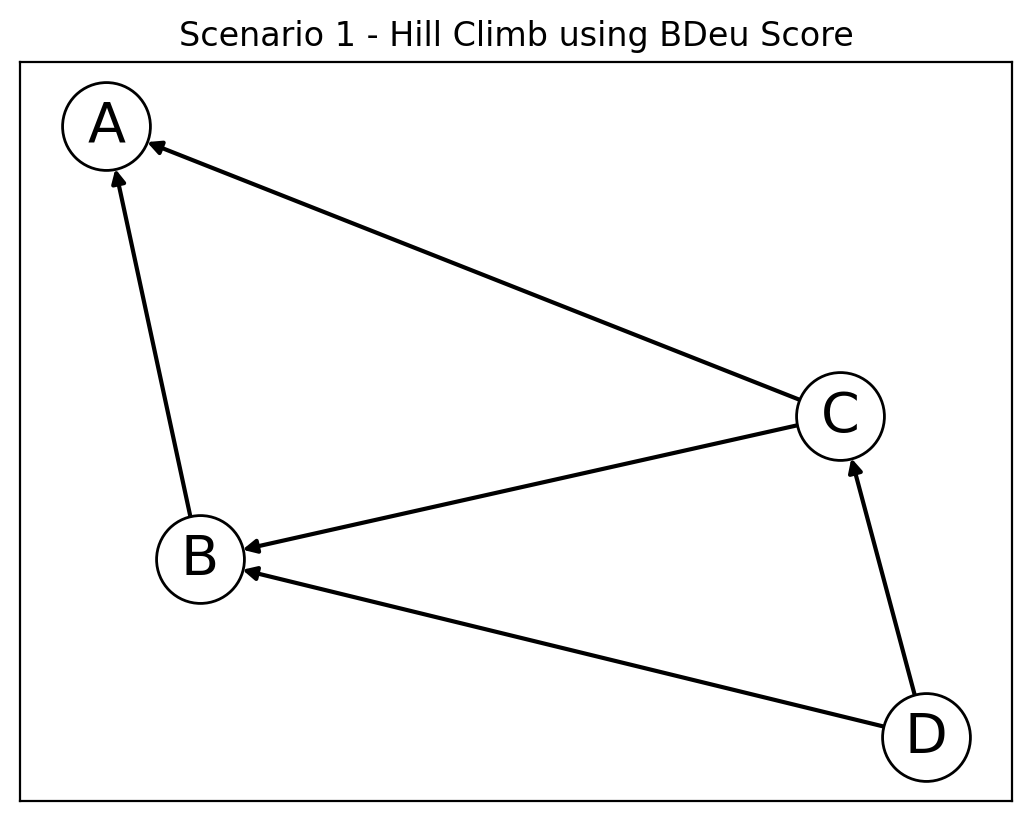

In [83]:
scoring_method = BDeuScore(data=df_scenario_1)    
est = HillClimbSearch(data=df_scenario_1)
network = est.estimate(scoring_method=scoring_method, show_progress=False)
G = nx.DiGraph(network.edges())

pos = nx.spring_layout(G, seed=13)  # positions for all nodes
options = {
    "font_size": 20,
    "node_size": 1000,
    "node_color": "white",
    "edgecolors": "black",
    "linewidths": 1,
    "width": 1.5,
}
nx.draw_networkx(G, pos, **options)
plt.title("Scenario 1 - Hill Climb using BDeu Score");

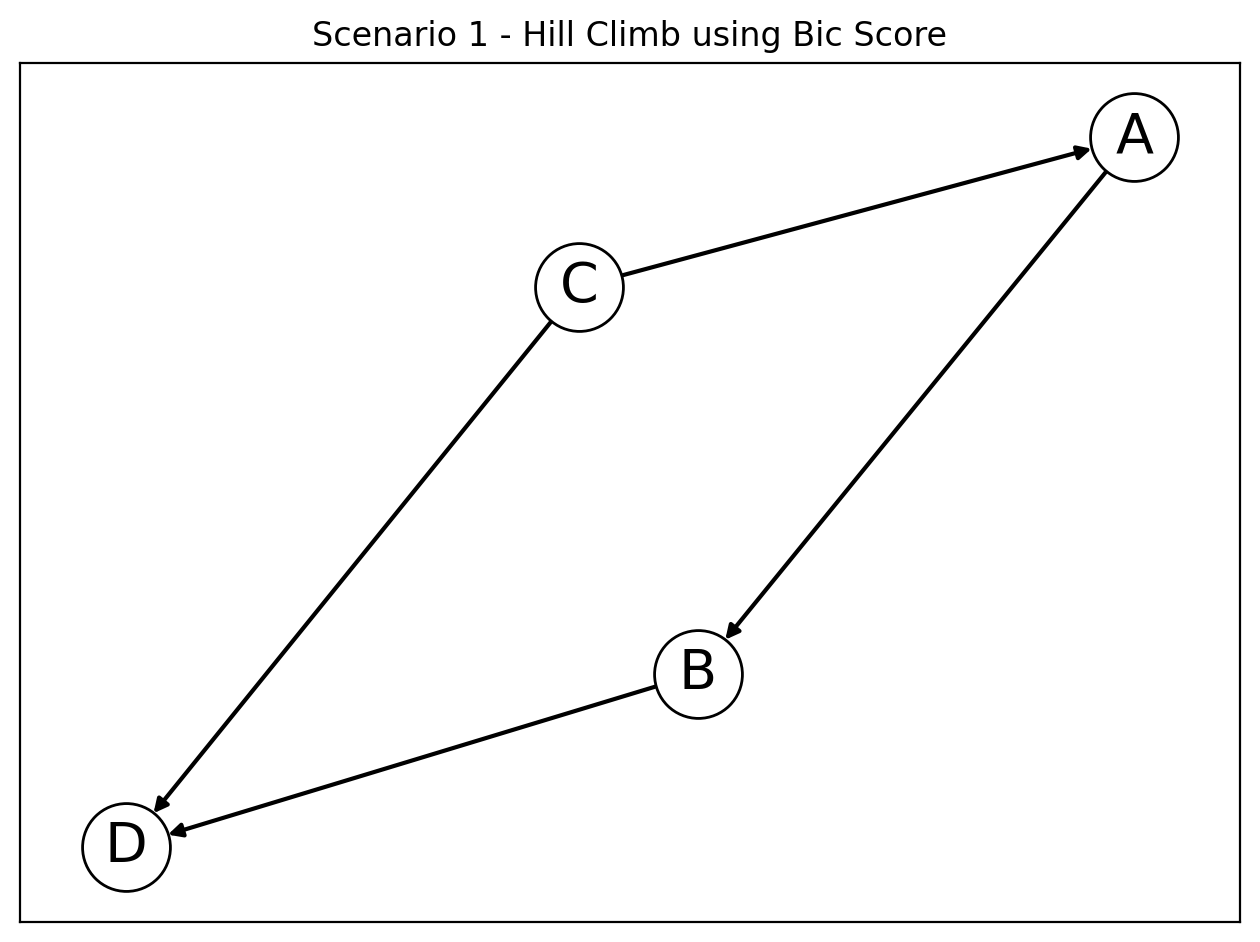

In [112]:
scoring_method = BicScore(data=df_scenario_1)    
est = HillClimbSearch(data=df_scenario_1)
network = est.estimate(scoring_method=scoring_method, show_progress=False)
G = nx.DiGraph(network.edges())

pos = nx.spring_layout(G, seed=42)  # positions for all nodes
options = {
    "font_size": 20,
    "node_size": 1000,
    "node_color": "white",
    "edgecolors": "black",
    "linewidths": 1,
    "width": 1.5,
}
nx.draw_networkx(G, pos, **options)
plt.title("Scenario 1 - Hill Climb using Bic Score");
plt.tight_layout();

##### Step 3: Evaluate Hill-Climb

We have the above list of edges, but imagine we knew nothing about the system which originated the data. 
How would you know this is right?

##### Step 4: Divide the dataset in chunks and learn a BN for each chunk

In [247]:
NUM_CHUNKS = 1_000
CHUNK_LENGHT = 100

chunks = []
edges = []

for i in tqdm(range(NUM_CHUNKS)):
    chunks.append(
        df_scenario_1.sample(n=CHUNK_LENGHT, random_state=i)
    )

    # BIC Score
    #scoring_method = BicScore(data=chunks[i])    

    scoring_method = BDeuScore(data=chunks[i])    
    
    est = HillClimbSearch(data=chunks[i])
    network = est.estimate(scoring_method=scoring_method, show_progress=False)
    edges.append(network.edges)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:11<00:00, 87.86it/s]


##### Step 5: Count the edges frequency

In [248]:
counted_edges_scenario_1 = count_edges(edges)
counted_edges_scenario_1.keys()

dict_keys([('A', 'B'), ('A', 'D'), ('A', 'C'), ('C', 'D'), ('B', 'D'), ('B', 'C')])

##### Step 6: Modeling

As described above, all possible edges appeared in some of the evaluated models. This will provide information to model the distributions of each edge existence or direction.

In [249]:
results_scenario_1 = dict()

for edge in count_edges(edges).keys():
    print('Learning distribution for ' + str(edge))
    res = learn_edge_distribution(counted_edges_scenario_1[edge],
                        edge=[edge[0], edge[1]],
                        destination_folder="", 
                        experiment_identifier="", 
                        mcmc_alg=pm.NUTS, 
                        chains=10, 
                        burnin=1000, 
                        draws=5000, 
                        nthreads=10)

    results_scenario_1[edge] = res

Learning distribution for ('A', 'B')


Multiprocess sampling (10 chains in 10 jobs)
INFO:pymc.sampling.mcmc:Multiprocess sampling (10 chains in 10 jobs)
NUTS: [true_fraction, concentration]
INFO:pymc.sampling.mcmc:NUTS: [true_fraction, concentration]


Output()

Sampling 10 chains for 1_000 tune and 5_000 draw iterations (10_000 + 50_000 draws total) took 11 seconds.
INFO:pymc.sampling.mcmc:Sampling 10 chains for 1_000 tune and 5_000 draw iterations (10_000 + 50_000 draws total) took 11 seconds.


Learning distribution for ('A', 'D')


...

Sampling 10 chains for 1_000 tune and 5_000 draw iterations (10_000 + 50_000 draws total) took 78 seconds.
INFO:pymc.sampling.mcmc:Sampling 10 chains for 1_000 tune and 5_000 draw iterations (10_000 + 50_000 draws total) took 78 seconds.
There were 4 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:There were 4 divergences after tuning. Increase `target_accept` or reparameterize.


Learning distribution for ('B', 'C')


Multiprocess sampling (10 chains in 10 jobs)
INFO:pymc.sampling.mcmc:Multiprocess sampling (10 chains in 10 jobs)
NUTS: [true_fraction, concentration]
INFO:pymc.sampling.mcmc:NUTS: [true_fraction, concentration]


Output()

Sampling 10 chains for 1_000 tune and 5_000 draw iterations (10_000 + 50_000 draws total) took 15 seconds.
INFO:pymc.sampling.mcmc:Sampling 10 chains for 1_000 tune and 5_000 draw iterations (10_000 + 50_000 draws total) took 15 seconds.


##### Step 7: Evaluate

In [223]:
def plot_pair(edge, data, ax=None):
    if (not ax):
        fig, ax = plt.subplots(1, 1, figsize=(2,5))
    
    ax.set_ylim(0,1)
    ax.set_xticks([0,1,2]);
    ax.set_xticklabels([r'$\times$', r'$\rightarrow$', r'$\leftarrow$']);
    ax.set_title(str(edge))
    ax.set_yticks(np.linspace(0,1, num=11))
    ax.set_yticks(np.linspace(0.05, 0.95, num=10), minor=True)
    ax.grid(c='grey', ls='--', lw = 0.25, alpha=0.5)
    ax.grid(which='minor', c='grey', ls='--', lw=0.25)
    
    sns.violinplot(
        results_scenario_1[edge]["true_fraction"], 
        cut=0, 
        density_norm="width", 
        palette=["#F57E8A", "#70D667", "#70D667"], 
        fill=True,
        inner="quart",
        linewidth=1,
        ax=ax
    );
    
    return ax

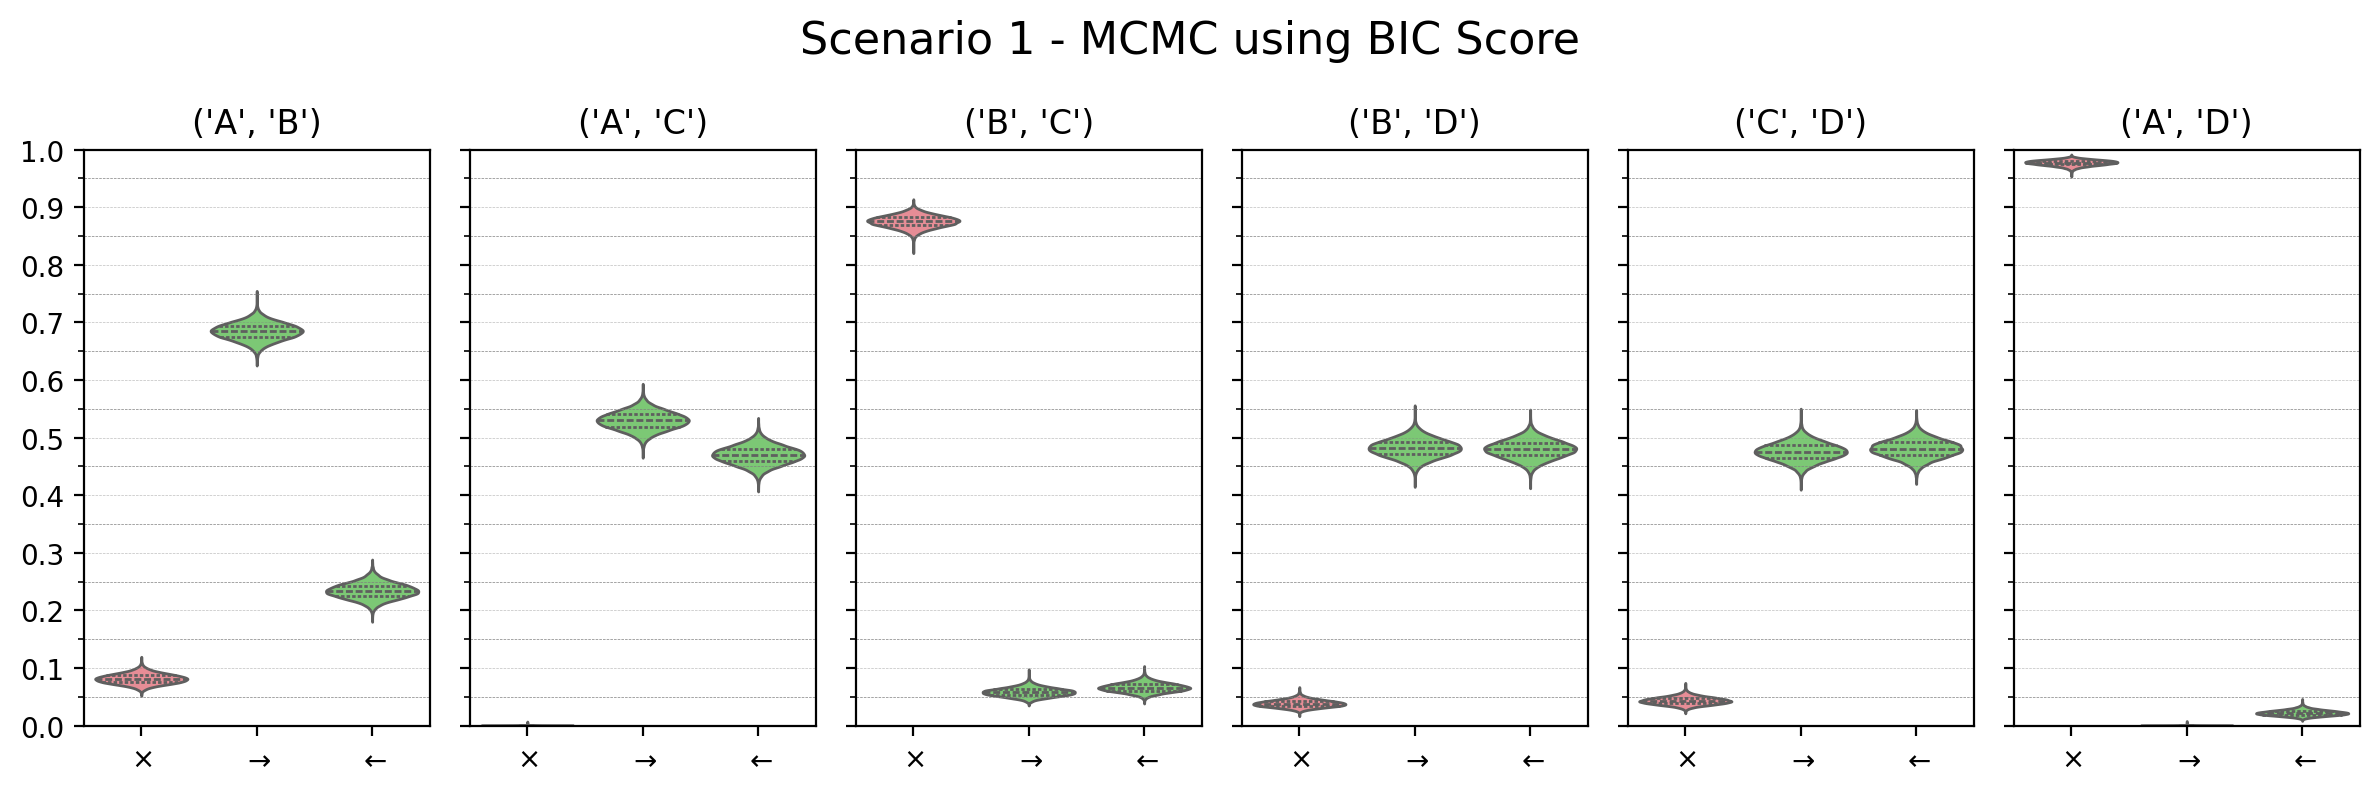

In [246]:
fig, axs = plt.subplots(1, 6, sharey=True, figsize=(12, 4))

fig.suptitle('Scenario 1 - MCMC using BIC Score', fontsize=16)

for i, edge in enumerate(results_scenario_1.keys()):
    plot_pair(edge, results_scenario_1, axs[i]);

fig.tight_layout();

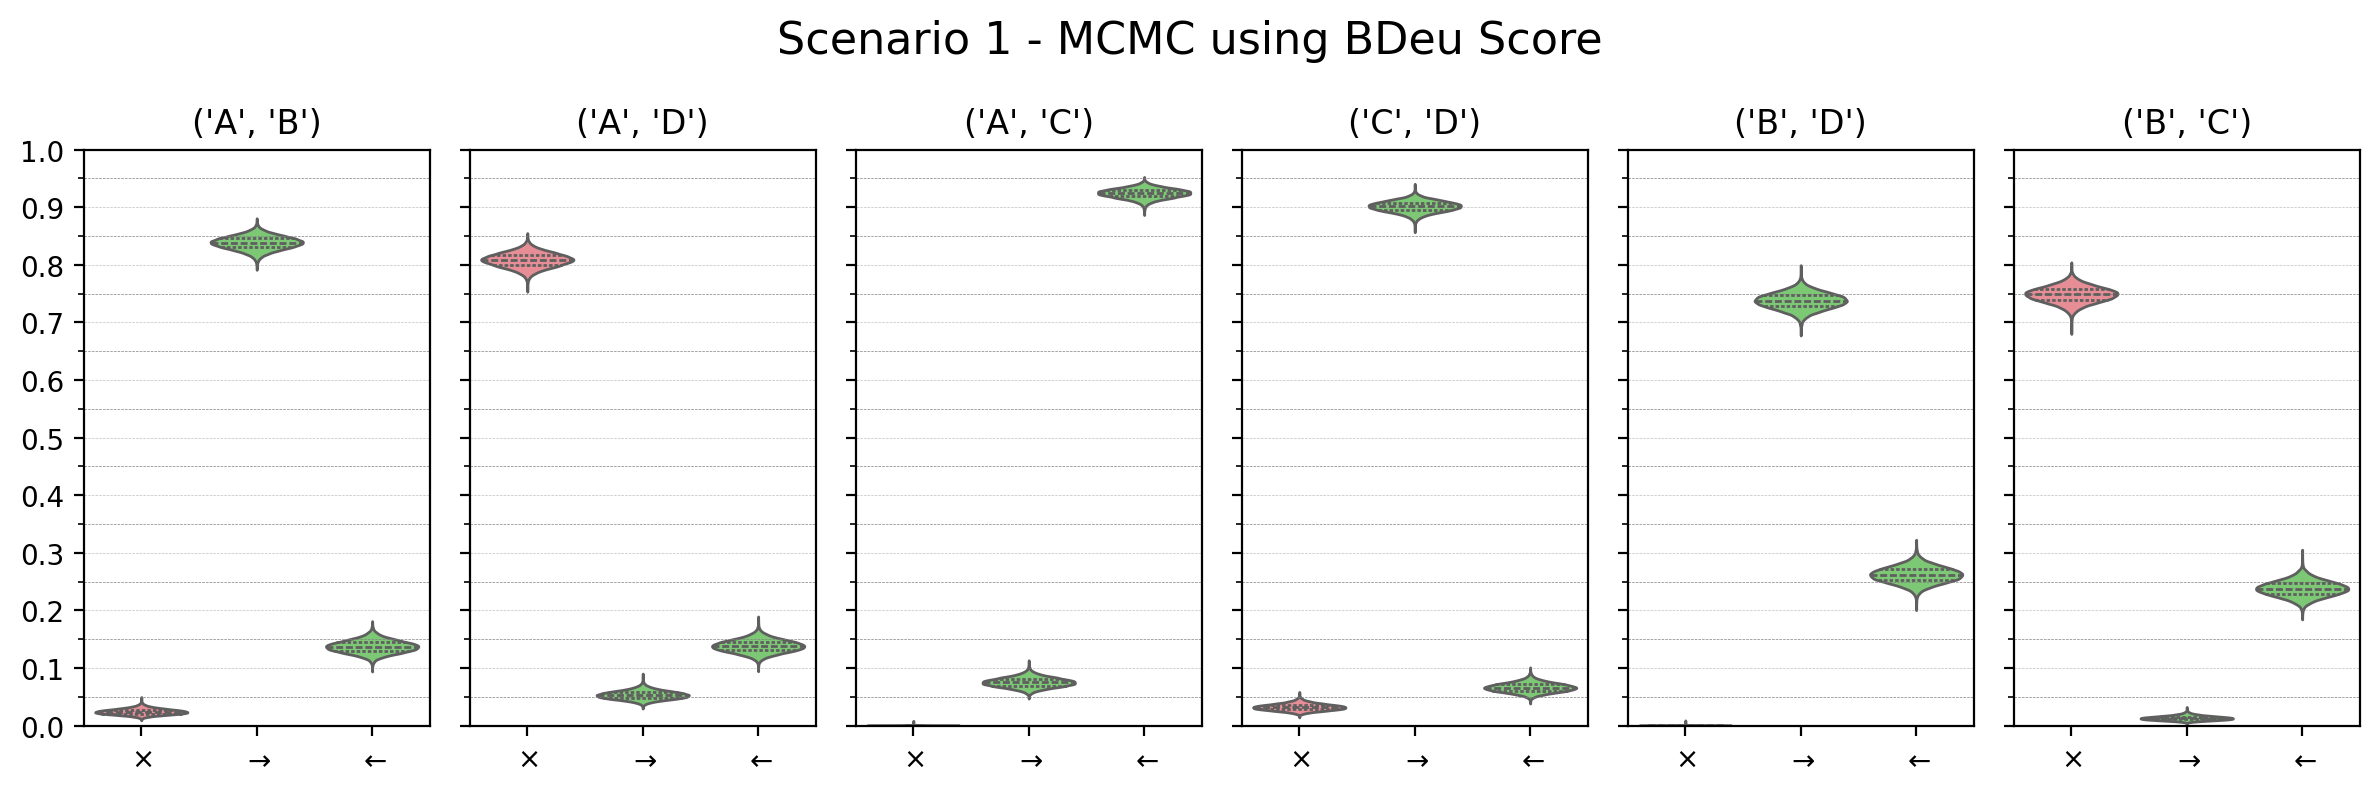

In [250]:
fig, axs = plt.subplots(1, 6, sharey=True, figsize=(12, 4))

fig.suptitle('Scenario 1 - MCMC using BDeu Score', fontsize=16)

for i, edge in enumerate(results_scenario_1.keys()):
    plot_pair(edge, results_scenario_1, axs[i]);

fig.tight_layout();